# TFM - Exploratory Data Analysis

## Objective

The main objective of this notebook is to explore the final integrated MLB hitters dataset in order to identify relevant patterns, distributions and relationships between salary and player performance variables.

This phase does not aim to build predictive models yet, but to understand the data from a descriptive and visual perspective.

Notebook: 04_Exploratory_Data_Analysis

Author: Ronald Báez

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display configuration
pd.set_option('display.max_columns', None)

# Load datase
df = pd.read_csv("../01_data/03_final_data/mlb_hitters_integrated.csv")

# Show first rows
df.head(3)

,rk,player,age,team,lg,war,g,pa,ab,r,h,2b,3b,hr,rbi,sb,cs,bb,so,ba,obp,slg,ops,ops_plus,roba,rbat_plus,tb,gidp,hbp,sh,sf,ibb,pos,awards,year,rownum,salary
0,384.0,a.j. ellis,36.0,MIA,NL,0.6,51.0,163.0,143.0,17.0,30.0,5.0,0.0,6.0,14.0,0.0,0.0,12.0,29.0,0.210,0.298,0.371,0.669,82.0,0.299,84.0,53.0,6.0,6.0,2.0,0.0,0.0,2H,no_award,2017,1,2500000
1,367.0,a.j. ellis,37.0,SDP,NL,0.2,66.0,183.0,151.0,19.0,41.0,8.0,0.0,1.0,15.0,0.0,0.0,26.0,37.0,0.272,0.378,0.344,0.722,104.0,0.326,105.0,52.0,2.0,1.0,3.0,2.0,1.0,2H/7D,no_award,2018,1,1250000
2,325.0,aaron altherr,25.0,PHI,NL,-0.2,57.0,227.0,198.0,23.0,39.0,6.0,0.0,4.0,22.0,7.0,2.0,23.0,69.0,0.197,0.300,0.288,0.587,59.0,0.288,65.0,57.0,4.0,6.0,0.0,0.0,2.0,978/H,no_award,2016,1,515500


### General dataset overview

Before analyzing distributions and relationships between variables, it is important to review the general structure of the dataset. This includes checking the number of records, available columns, data types, seasons included, unique players and missing values.

In [2]:
# Dataset dimensions
print(f"The dataset contains {df.shape[0]} rows and {df.shape[1]} columns.")
print(f"Seasons included: {df['year'].min()} - {df['year'].max()}")
print(f"Unique players: {df['player'].nunique()}")

The dataset contains 3684 rows and 37 columns.
Seasons included: 2015 - 2024
Unique players: 1033


In [3]:
# Check missing values
missing_values = df.isnull().sum().sort_values(ascending=False)

missing_values[missing_values > 0]

Series([], dtype: int64)

### Descriptive statistics

This section provides a first statistical overview of the main numerical variables in the dataset. The objective is to understand the central tendency, dispersion and range of the most relevant variables before moving into visual analysis.

In [4]:
# Main variables for descriptive analysis
main_variables = [
    'age', 'salary', 'war', 'g', 'pa', 
    'hr', 'roba', 'rbi', 'bb', 'so', 
    'sb', 'ba', 'obp', 'slg', 'ops', 
    'ops_plus'
    ]
df[main_variables].describe().T


,count,mean,std,min,25%,50%,75%,max
age,3684.0,2.822258e+01,3.755907e+00,19.000,25.00000,28.000,31.000,4.300000e+01
salary,3684.0,4.687144e+06,6.702141e+06,32230.000,545000.00000,1430137.500,6000000.000,4.417500e+07
war,3684.0,1.491015e+00,1.907962e+00,-3.300,0.10000,1.100,2.500,1.080000e+01
g,3684.0,1.056754e+02,3.775724e+01,26.000,73.00000,110.000,140.000,1.620000e+02
pa,3684.0,3.933089e+02,1.768561e+02,102.000,233.00000,382.000,547.000,7.530000e+02
hr,3684.0,1.297530e+01,9.916852e+00,0.000,5.00000,10.000,18.000,6.200000e+01
roba,3684.0,3.235592e-01,4.131821e-02,0.143,0.29600,0.324,0.350,4.940000e-01
rbi,3684.0,4.627850e+01,2.695246e+01,0.000,24.00000,42.000,64.000,1.440000e+02
bb,3684.0,3.375461e+01,2.141681e+01,1.000,17.00000,29.000,46.000,1.450000e+02
so,3684.0,8.412161e+01,3.976240e+01,7.000,52.00000,79.000,111.000,2.190000e+02


In [5]:
# Overview of categorical variables
categorical_variables = ['player', 'team', 'lg', 'pos']
df[categorical_variables].describe()

,player,team,lg,pos
count,3684,3684,3684,3684
unique,1033,33,3,1710
top,wilmer flores,2TM,AL,6/H
freq,10,324,1782,100


### Salary distribution

Salary is one of the main variables of interest in this project. Before analyzing its relationship with player performance, it is important to understand how salaries are distributed across the dataset.

Professional sports salary data usually presents high dispersion, with a small number of players earning very high salaries and many players concentrated in lower or medium salary ranges. For this reason, both the original salary distribution and a logarithmic transformation will be reviewed.

In [6]:
# Create salary variables for visualization
df['salary_millions'] = df['salary'] / 1_000_000
df['log_salary'] = np.log1p(df['salary'])

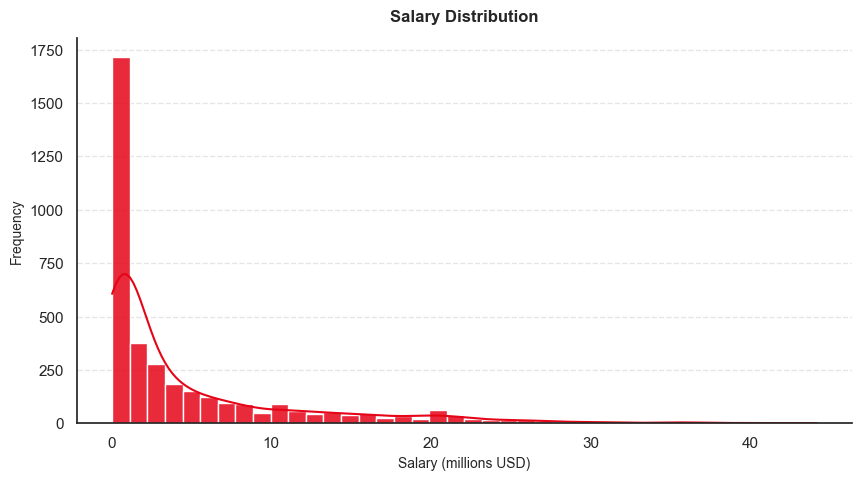

In [43]:
# Salary distribution in millions
plt.figure(figsize=(10, 5))
sns.set_theme(style="white")
sns.histplot(df['salary_millions'], bins=40, kde=True,
             color="#e60417f8", edgecolor='white', alpha=0.85
)
plt.grid(axis='y', linestyle='--', alpha=0.5, color="#ccccccb5")
sns.despine()
plt.title('Salary Distribution', fontsize=12, fontweight='bold', pad=12)
plt.xlabel('Salary (millions USD)', fontsize=10)
plt.ylabel('Frequency', fontsize=10)
plt.show()

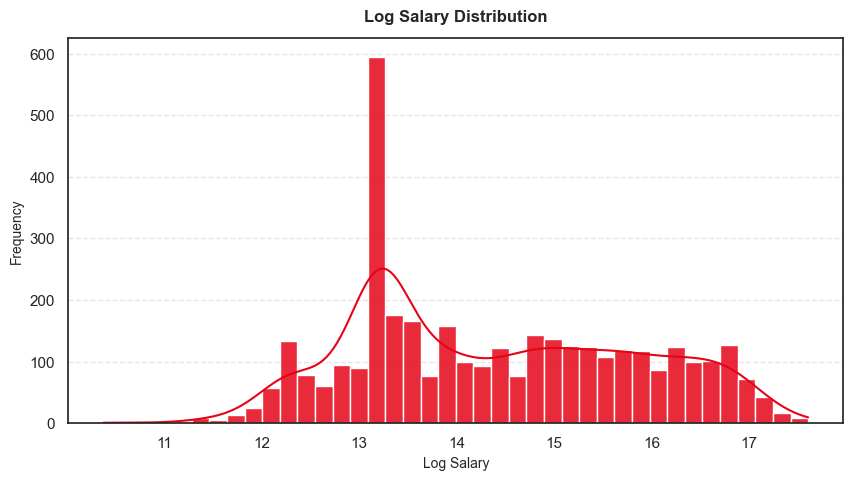

In [44]:
# Log salary distribution
plt.figure(figsize=(10, 5))
sns.histplot(df['log_salary'], bins=40, kde=True,
             color="#e60417f8", edgecolor='white', alpha=0.85
)
plt.grid(axis='y', linestyle='--', alpha=0.5, color="#ccccccb5")
plt.title('Log Salary Distribution', fontsize=12, fontweight='bold', pad=12)
plt.xlabel('Log Salary', fontsize=10)
plt.ylabel('Frequency', fontsize=10)
plt.show()

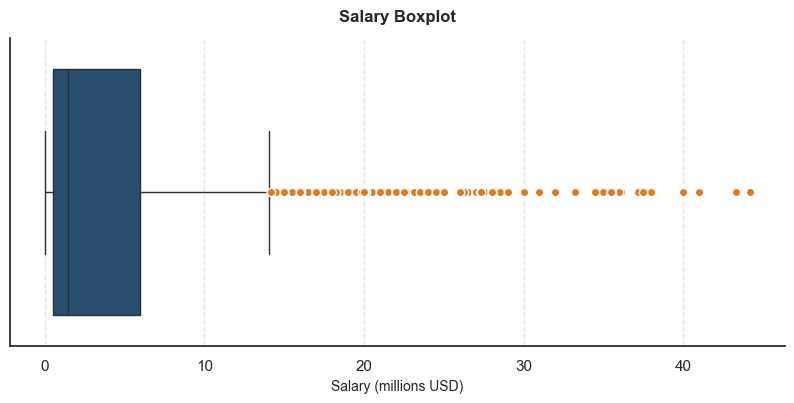

In [9]:
# Salary boxplot
plt.figure(figsize=(10, 4))
sns.set_theme(style="white")
sns.boxplot(x=df['salary_millions'], color='#1f4e79', flierprops={'markerfacecolor': '#de7a22', 'markeredgecolor': 'white'})
plt.grid(axis='x', linestyle='--', alpha=0.5, color='#cccccc')
sns.despine()
plt.title('Salary Boxplot', fontsize=12, fontweight='bold', pad=12)
plt.xlabel('Salary (millions USD)', fontsize=10)
plt.show()

### Offensive performance distribution

This section analyzes the distribution of the main offensive performance variables. In order to make the analysis more aligned with the objective of the project, the variables are divided into two groups: traditional offensive metrics and sabermetric or advanced metrics.

Traditional metrics represent the most common batting indicators historically used to evaluate hitters, while sabermetric metrics provide a broader and more analytical view of player contribution.

For each variable, a histogram and a boxplot are shown together in a single figure to review both the distribution and the presence of potential outliers.

In [10]:
# Traditional and sabermetric offensive metrics
traditional_metrics = ['hr', 'rbi', 'bb', 'so', 'sb', 'ba']

sabermetric_metrics = ['war', 'roba', 'ops', 'ops_plus', 'obp', 'slg']

In [11]:
# Function to plot histogram and boxplot together
def plot_distribution_with_boxplot(data, variables, group_name):
    for variable in variables:
        fig, axes = plt.subplots(1, 2, figsize=(13, 4))
        sns.set_theme(style="white")

        # Histogram
        sns.histplot(
            data=data,
            x=variable,
            bins=40,
            kde=True,
            color="#e41b5be3",
            edgecolor="white",
            alpha=0.85,
            ax=axes[0]
        )

        axes[0].grid(axis='y', linestyle='--', alpha=0.5, color="#dcddd3")
        axes[0].set_title(f'{variable.upper()} Distribution', fontsize=12, fontweight='bold', pad=12)
        axes[0].set_xlabel(variable.upper(), fontsize=10)
        axes[0].set_ylabel('Frequency', fontsize=10)

        # Boxplot
        sns.boxplot(
            x=data[variable],
            color="#1f4e79",
            flierprops={
                'markerfacecolor': "#ec8a34",
                'markeredgecolor': 'white'
            },
            ax=axes[1]
        )

        axes[1].grid(axis='x', linestyle='--', alpha=0.5, color="#cccccc")
        axes[1].set_title(f'{variable.upper()} Boxplot', fontsize=12, fontweight='bold', pad=12)
        axes[1].set_xlabel(variable.upper(), fontsize=10)

        sns.despine()
        fig.suptitle(f'{group_name}: {variable.upper()}', fontsize=13, fontweight='bold', y=1.05)

        plt.tight_layout()
        plt.show()

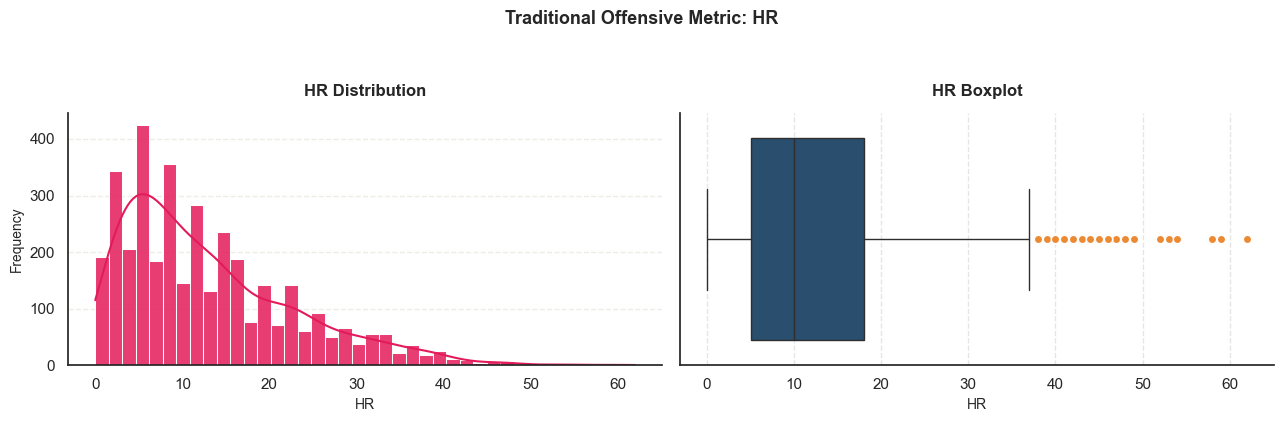

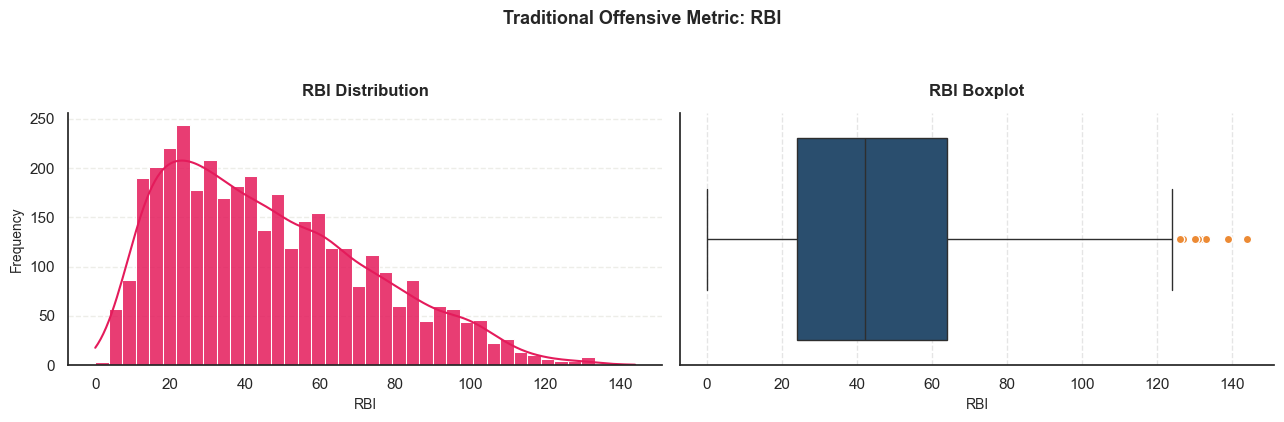

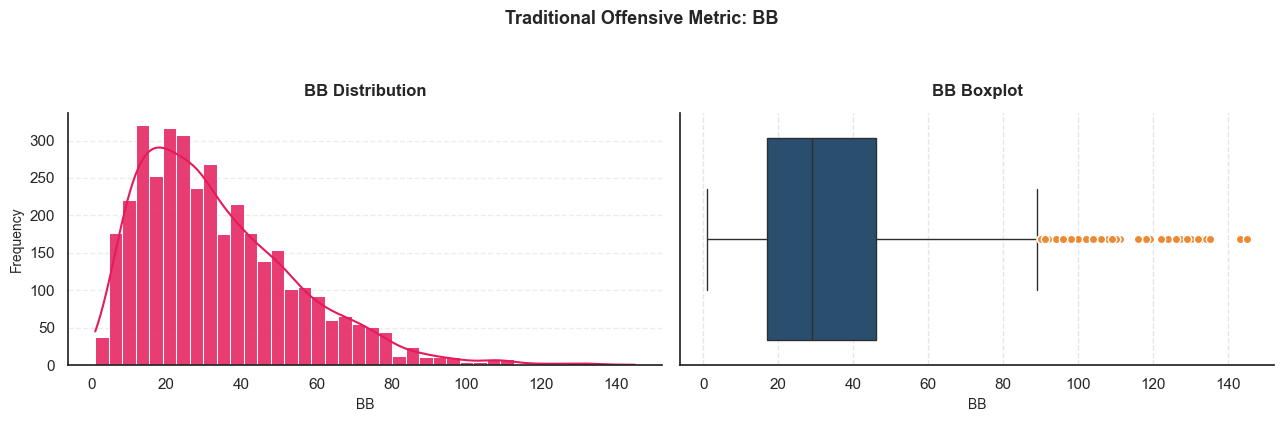

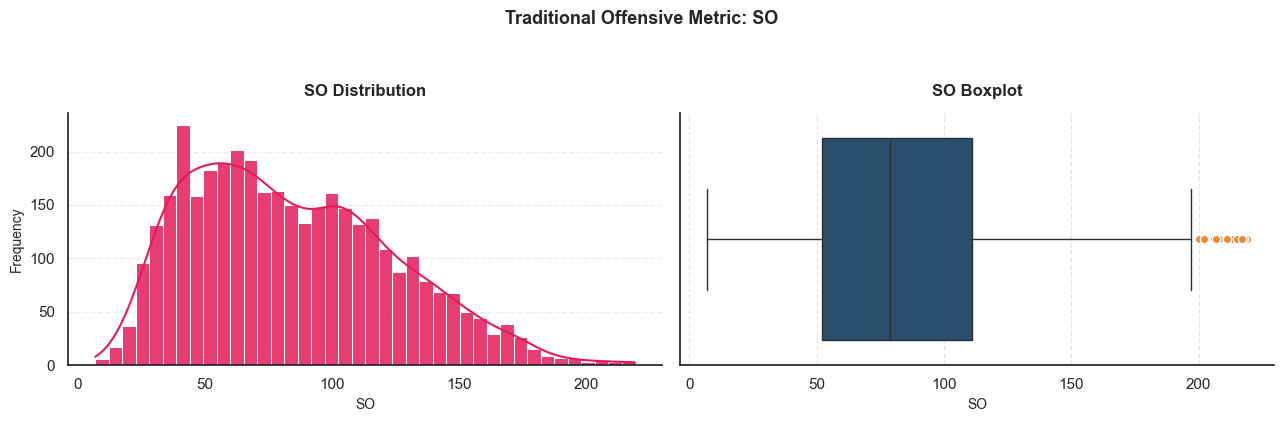

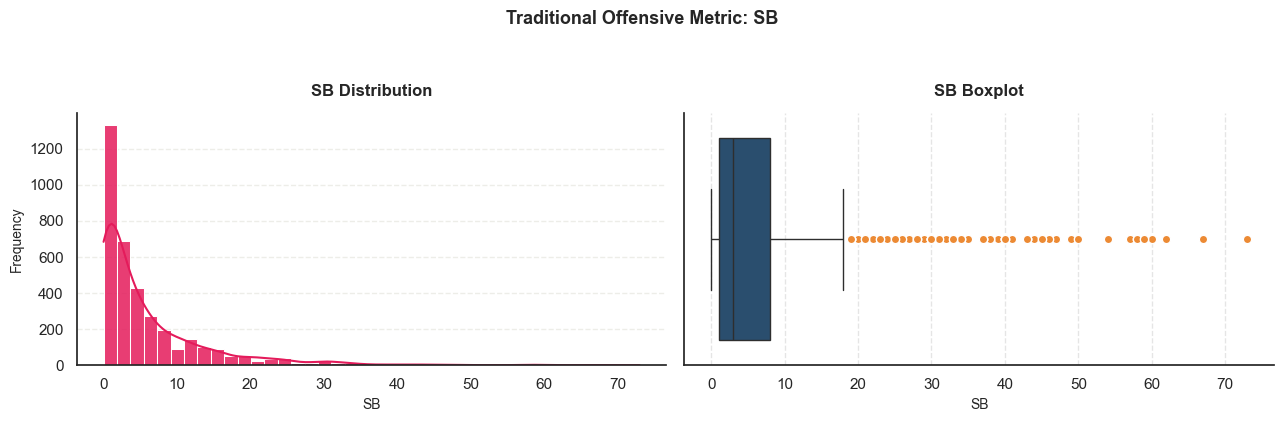

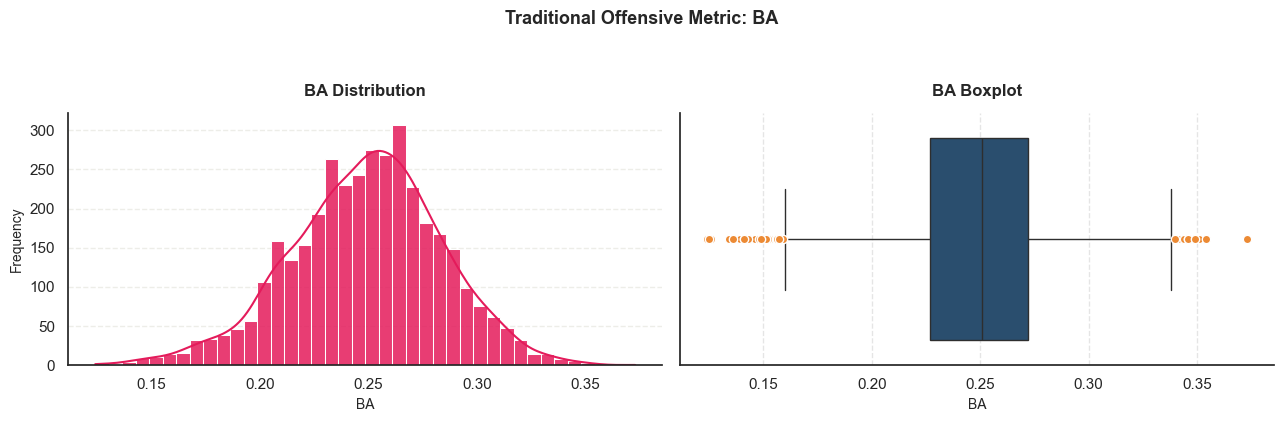

In [12]:
# Traditional offensive metrics distribution
plot_distribution_with_boxplot(df, traditional_metrics, 'Traditional Offensive Metric')

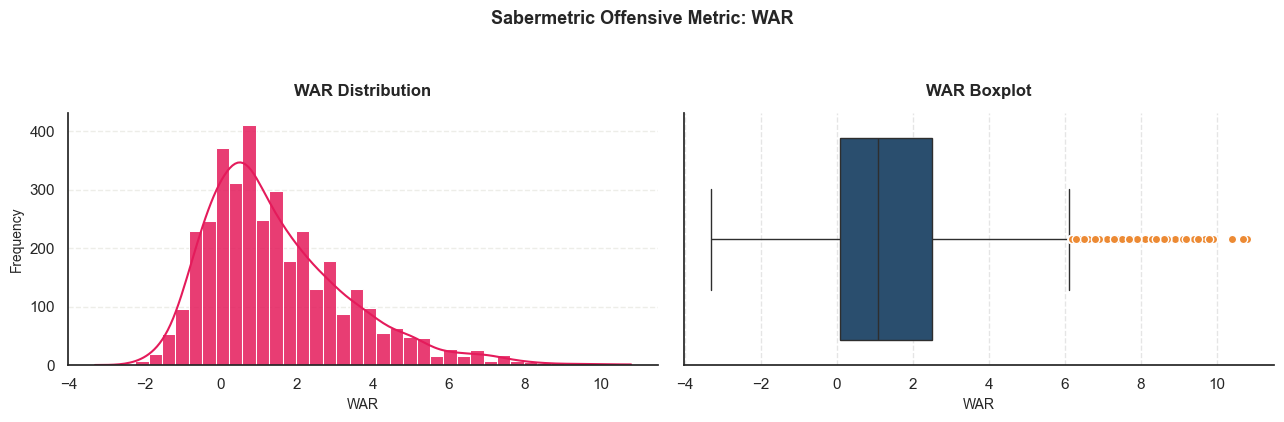

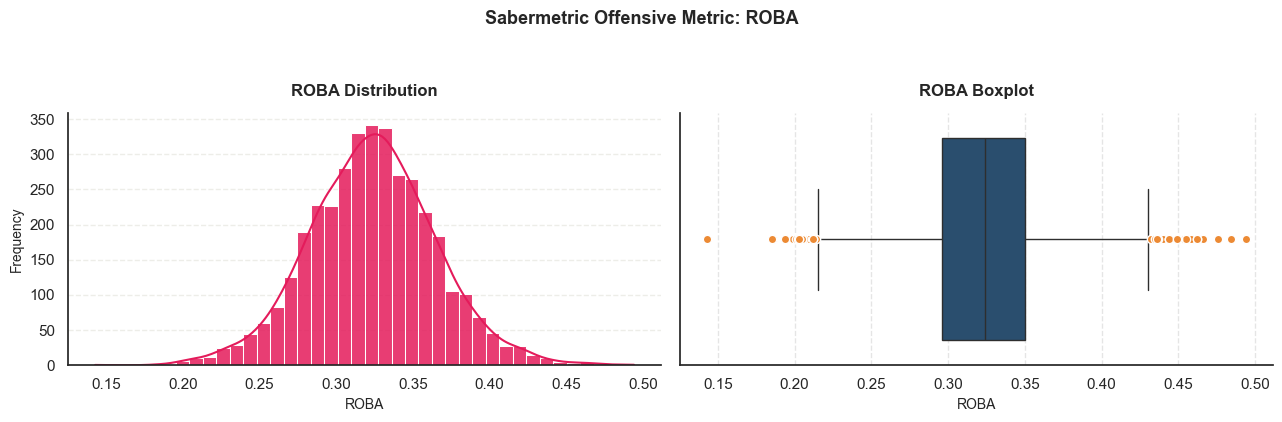

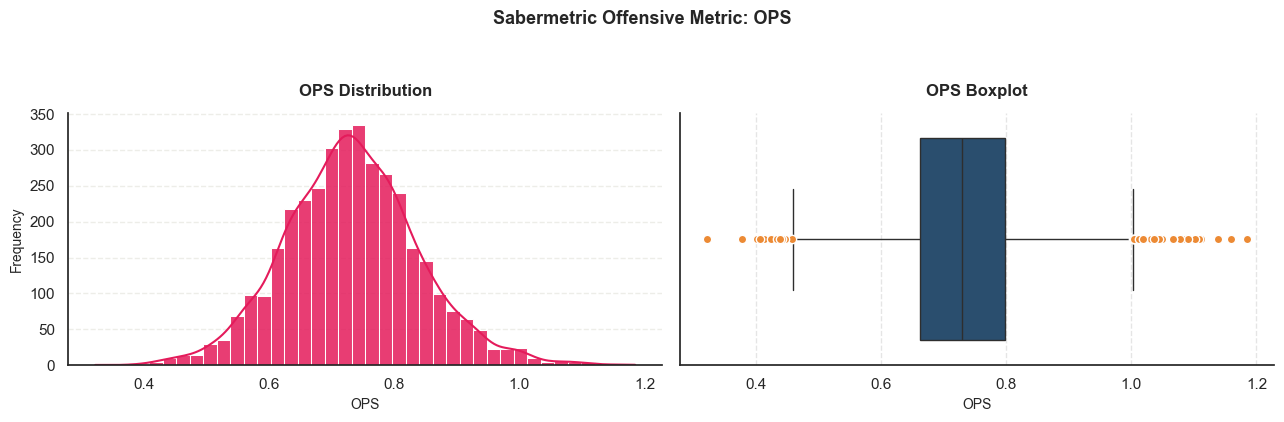

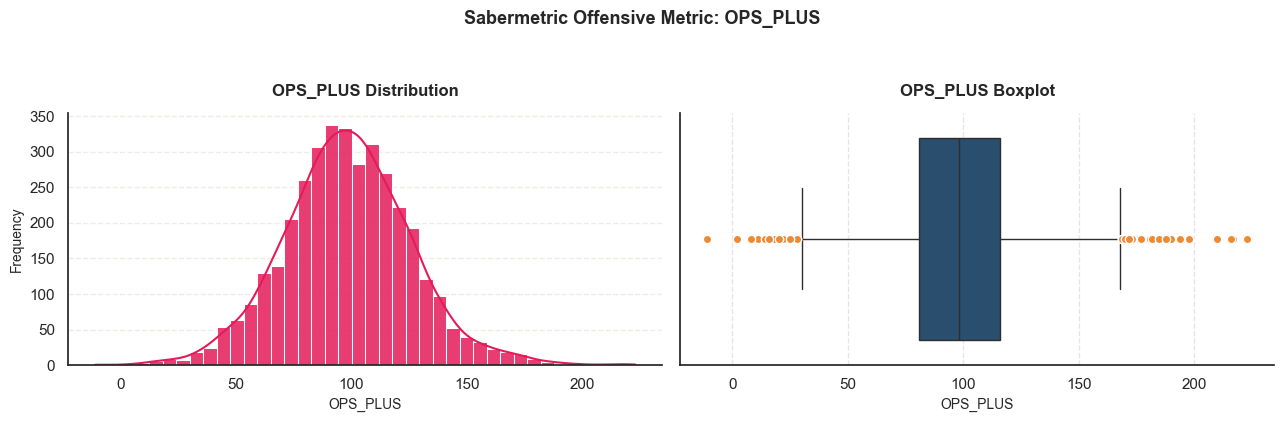

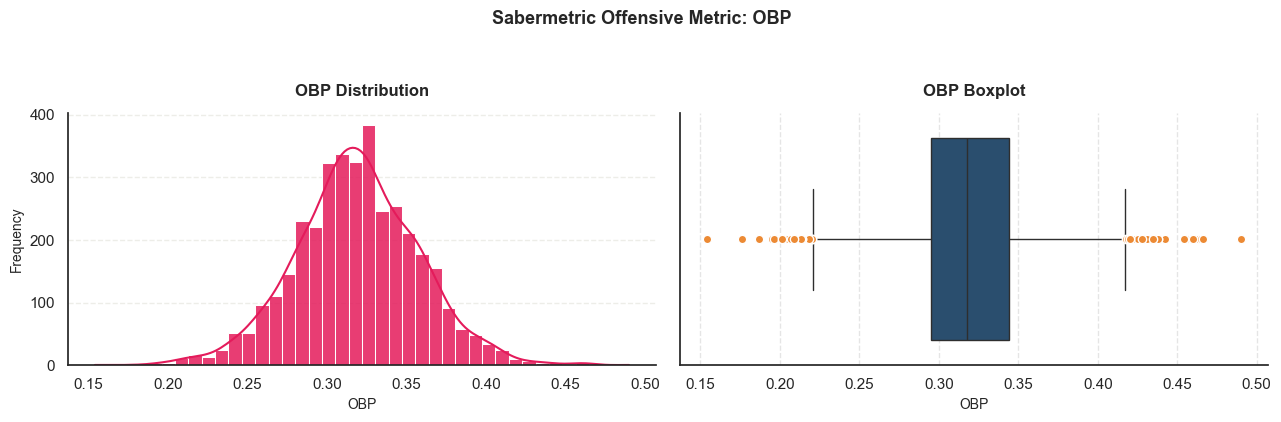

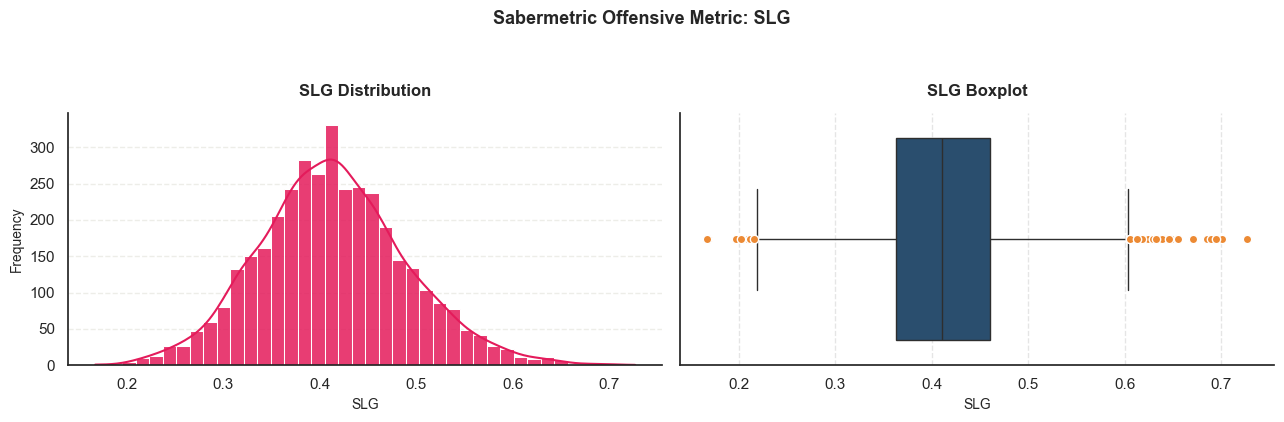

In [13]:
# Sabermetric offensive metrics distribution
plot_distribution_with_boxplot(df, sabermetric_metrics, 'Sabermetric Offensive Metric')

### Salary vs performance analysis

This section explores the relationship between player salary and the main offensive performance variables. Since salary presents a highly skewed distribution, the logarithmic transformation of salary is used to improve visualization and interpretation.

The objective is not to establish causality, but to identify initial patterns between compensation and player performance.

In [14]:
# Variables selected to analyze their relationship with salary
salary_performance_variables = [
    'war', 'roba', 'ops', 'ops_plus', 'hr', 'rbi', 'pa'
]

# Correlation with salary and log salary
salary_correlations = df[
    ['salary_millions', 'log_salary'] + salary_performance_variables
].corr()[['salary_millions', 'log_salary']].loc[salary_performance_variables]

salary_correlations.sort_values(by='log_salary', ascending=False)

,salary_millions,log_salary
pa,0.379986,0.475755
rbi,0.400118,0.460722
hr,0.366088,0.395420
war,0.272785,0.301834
ops_plus,0.274221,0.272394
ops,0.261660,0.259941
roba,0.259382,0.259111


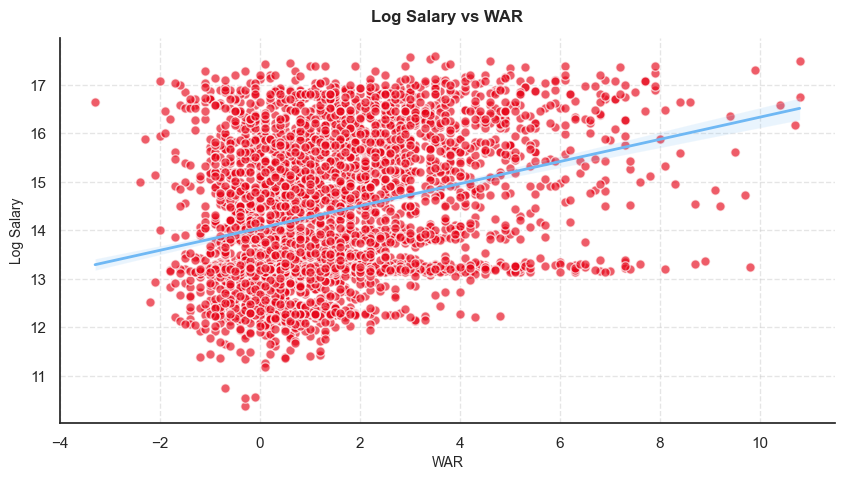

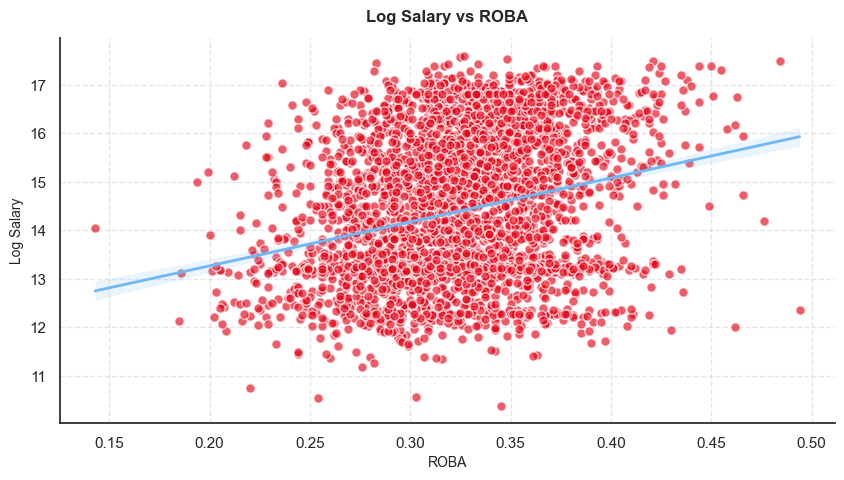

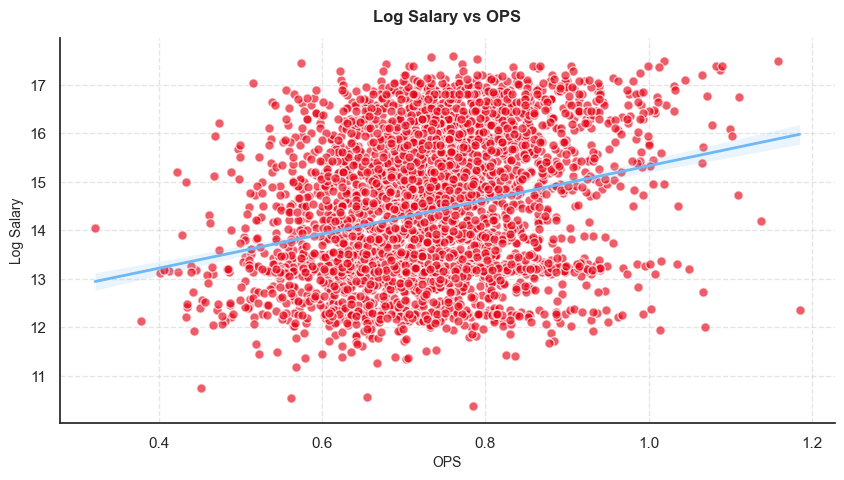

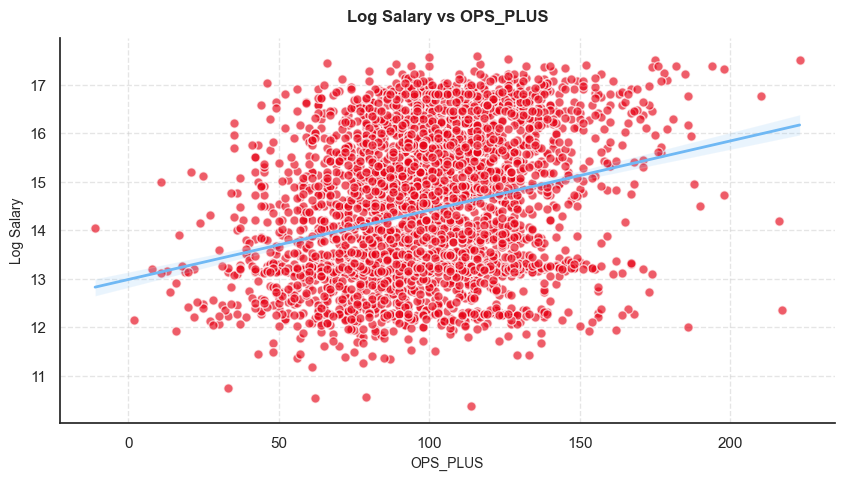

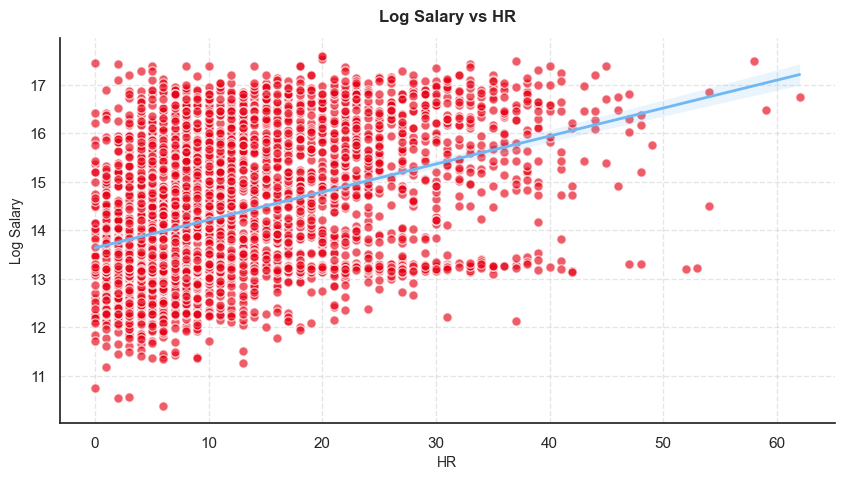

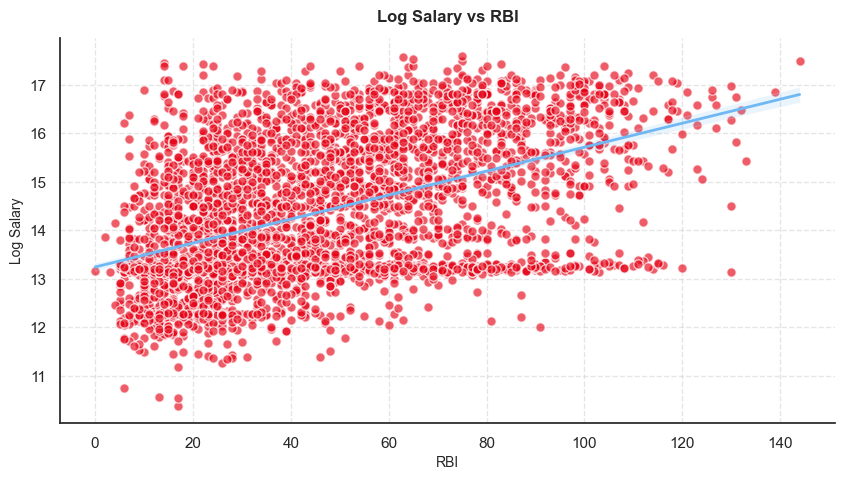

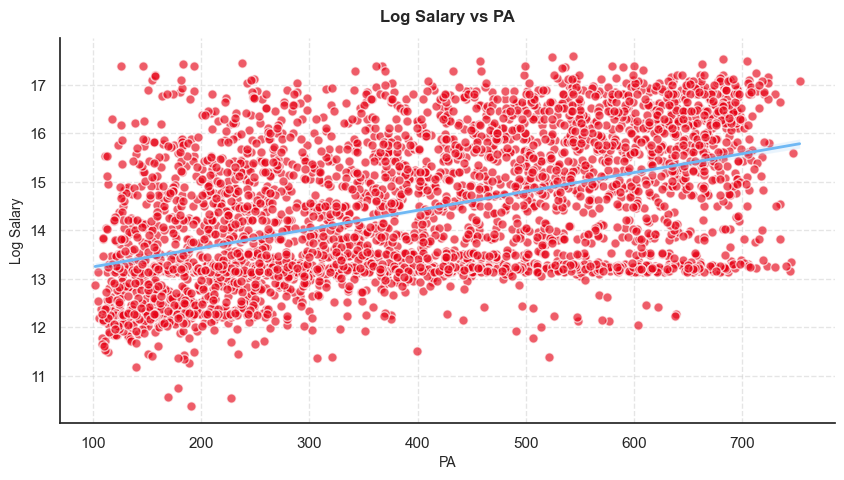

In [46]:
# Scatter plots: performance variables vs log salary
for variable in salary_performance_variables:
    plt.figure(figsize=(10, 5))
    sns.set_theme(style="white")

    sns.regplot(
        data=df,
        x=variable,
        y='log_salary',
        scatter_kws={
            'color': '#e60417f8',
            'alpha': 0.65,
            's': 45,
            'edgecolor': 'white'
            
        },
        line_kws={
            'color': "#6fb8f4",
            'linewidth': 2
        }
    )

    plt.grid(axis='both', linestyle='--', alpha=0.5, color='#cccccc')
    sns.despine()

    plt.title(f'Log Salary vs {variable.upper()}', fontsize=12, fontweight='bold', pad=12)
    plt.xlabel(variable.upper(), fontsize=10)
    plt.ylabel('Log Salary', fontsize=10)

    plt.show()

### Temporal analysis

This section analyzes how the dataset behaves across seasons. The objective is to understand the distribution of records by year and observe the evolution of average salary and key performance indicators over time.

This analysis helps identify possible temporal patterns that may influence both player compensation and offensive performance.

In [16]:
# Summary by season
year_summary = df.groupby('year').agg(
    records=('player', 'count'),
    unique_players=('player', 'nunique'),
    avg_salary_millions=('salary_millions', 'mean'),
    median_salary_millions=('salary_millions', 'median'),
    avg_war=('war', 'mean'),
    avg_ops_plus=('ops_plus', 'mean'),
    avg_roba=('roba', 'mean')
).reset_index()

year_summary

,year,records,unique_players,avg_salary_millions,median_salary_millions,avg_war,avg_ops_plus,avg_roba
0,2015,337,337,5.344225,2.640000,1.568843,96.151335,0.321208
1,2016,343,343,5.228066,2.500000,1.624198,96.603499,0.326493
2,2017,409,409,4.305372,1.300000,1.475550,97.276284,0.329535
3,2018,405,405,4.261297,0.925000,1.456790,96.812346,0.322825
4,2019,407,407,4.190087,0.700000,1.483538,97.503686,0.329032
5,2020,263,263,2.607307,1.037037,0.798859,104.532319,0.334148
6,2021,388,388,4.322413,1.250000,1.551289,98.597938,0.323423
7,2022,379,379,5.155078,1.652736,1.587863,98.567282,0.313546
8,2023,374,374,5.512192,1.364083,1.589037,99.478610,0.323088
9,2024,379,379,5.548725,1.350000,1.587599,98.891821,0.314723


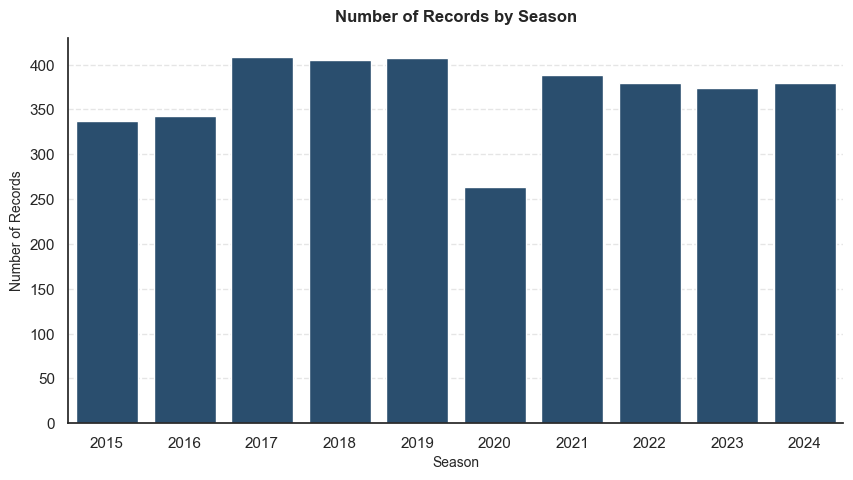

In [17]:
# Number of records by season
plt.figure(figsize=(10, 5))
sns.set_theme(style="white")

sns.barplot(
    data=year_summary,
    x='year',
    y='records',
    color="#1f4e79",
    edgecolor="white"
)

plt.grid(axis='y', linestyle='--', alpha=0.5, color="#cccccc")
sns.despine()

plt.title('Number of Records by Season', fontsize=12, fontweight='bold', pad=12)
plt.xlabel('Season', fontsize=10)
plt.ylabel('Number of Records', fontsize=10)

plt.show()

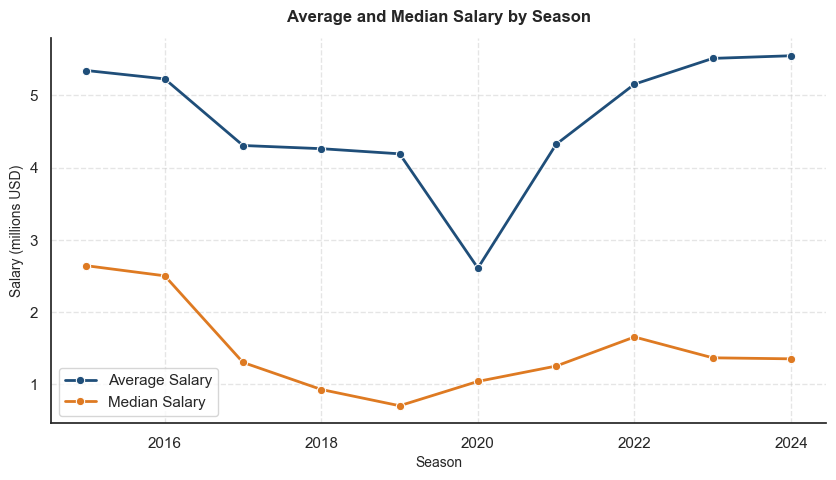

In [18]:
# Average and median salary by season
plt.figure(figsize=(10, 5))
sns.set_theme(style="white")

sns.lineplot(
    data=year_summary,
    x='year',
    y='avg_salary_millions',
    marker='o',
    color="#1f4e79",
    linewidth=2,
    label='Average Salary'
)

sns.lineplot(
    data=year_summary,
    x='year',
    y='median_salary_millions',
    marker='o',
    color="#de7a22",
    linewidth=2,
    label='Median Salary'
)

plt.grid(axis='both', linestyle='--', alpha=0.5, color="#cccccc")
sns.despine()

plt.title('Average and Median Salary by Season', fontsize=12, fontweight='bold', pad=12)
plt.xlabel('Season', fontsize=10)
plt.ylabel('Salary (millions USD)', fontsize=10)
plt.legend()

plt.show()

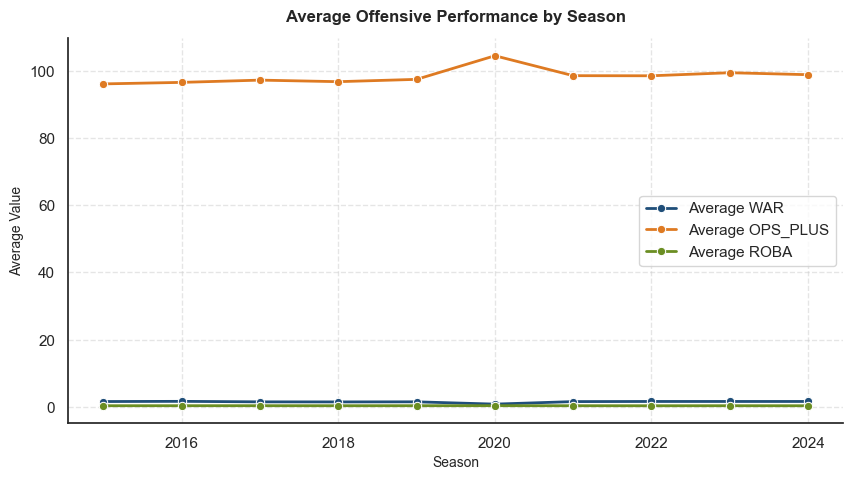

In [19]:
# Average offensive performance by season
plt.figure(figsize=(10, 5))
sns.set_theme(style="white")

sns.lineplot(
    data=year_summary,
    x='year',
    y='avg_war',
    marker='o',
    color="#1f4e79",
    linewidth=2,
    label='Average WAR'
)

sns.lineplot(
    data=year_summary,
    x='year',
    y='avg_ops_plus',
    marker='o',
    color="#de7a22",
    linewidth=2,
    label='Average OPS_PLUS'
)

sns.lineplot(
    data=year_summary,
    x='year',
    y='avg_roba',
    marker='o',
    color="#6b8e23",
    linewidth=2,
    label='Average ROBA'
)

plt.grid(axis='both', linestyle='--', alpha=0.5, color="#cccccc")
sns.despine()

plt.title('Average Offensive Performance by Season', fontsize=12, fontweight='bold', pad=12)
plt.xlabel('Season', fontsize=10)
plt.ylabel('Average Value', fontsize=10)
plt.legend()

plt.show()

### Age analysis

This section analyzes the relationship between player age, salary and offensive performance. Age is an important variable in professional sports because it may influence both player development and contract value.

The objective is to observe how salary and performance indicators behave across different ages.

In [20]:
# Summary by player age
age_summary = df.groupby('age').agg(
    records=('player', 'count'),
    unique_players=('player', 'nunique'),
    avg_salary_millions=('salary_millions', 'mean'),
    median_salary_millions=('salary_millions', 'median'),
    avg_war=('war', 'mean'),
    avg_ops_plus=('ops_plus', 'mean'),
    avg_roba=('roba', 'mean')
).reset_index()

age_summary

,age,records,unique_players,avg_salary_millions,median_salary_millions,avg_war,avg_ops_plus,avg_roba
0,19.0,1,1,0.392620,0.392620,3.000000,142.000000,0.396000
1,20.0,10,10,0.849837,0.467179,2.530000,118.200000,0.353900
2,21.0,38,38,0.655886,0.364818,1.447368,101.500000,0.322895
3,22.0,88,88,1.219459,0.535000,2.039773,99.590909,0.324750
4,23.0,184,184,0.834451,0.513672,1.466848,96.809783,0.321755
5,24.0,291,291,1.163688,0.542500,1.493471,97.501718,0.323595
6,25.0,349,349,1.632721,0.569500,1.585960,97.063037,0.321043
7,26.0,391,391,2.237278,0.597500,1.601790,97.572890,0.322711
8,27.0,380,380,3.113883,1.027269,1.737368,99.760526,0.325197
9,28.0,358,358,4.169937,1.950000,1.542737,96.893855,0.321265


In [21]:
# Filter ages with enough records for more stable visualization
age_summary_filtered = age_summary[age_summary['records'] >= 10]

age_summary_filtered

,age,records,unique_players,avg_salary_millions,median_salary_millions,avg_war,avg_ops_plus,avg_roba
1,20.0,10,10,0.849837,0.467179,2.530000,118.200000,0.353900
2,21.0,38,38,0.655886,0.364818,1.447368,101.500000,0.322895
3,22.0,88,88,1.219459,0.535000,2.039773,99.590909,0.324750
4,23.0,184,184,0.834451,0.513672,1.466848,96.809783,0.321755
5,24.0,291,291,1.163688,0.542500,1.493471,97.501718,0.323595
6,25.0,349,349,1.632721,0.569500,1.585960,97.063037,0.321043
7,26.0,391,391,2.237278,0.597500,1.601790,97.572890,0.322711
8,27.0,380,380,3.113883,1.027269,1.737368,99.760526,0.325197
9,28.0,358,358,4.169937,1.950000,1.542737,96.893855,0.321265
10,29.0,307,307,5.731540,2.950000,1.788925,101.035831,0.326935


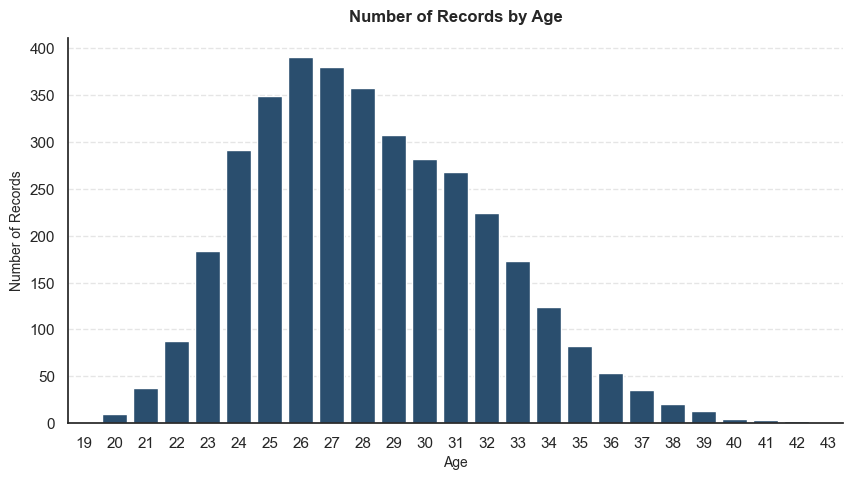

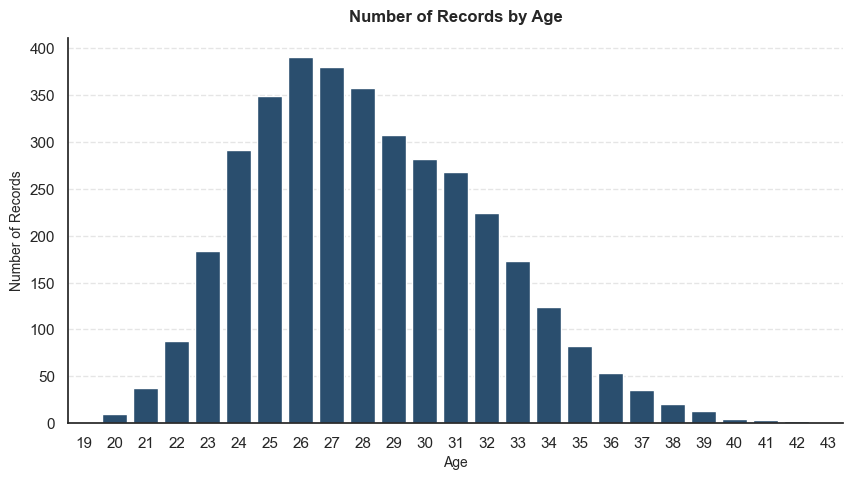

In [22]:
# Convert age to integer for better visualization
age_summary['age'] = age_summary['age'].astype(int)

# Number of records by age
plt.figure(figsize=(10, 5))
sns.set_theme(style="white")

sns.barplot(
    data=age_summary,
    x='age',
    y='records',
    color="#1f4e79",
    edgecolor="white"
)

plt.grid(axis='y', linestyle='--', alpha=0.5, color="#cccccc")
sns.despine()

plt.title('Number of Records by Age', fontsize=12, fontweight='bold', pad=12)
plt.xlabel('Age', fontsize=10)
plt.ylabel('Number of Records', fontsize=10)

plt.show()

# Number of records by age
plt.figure(figsize=(10, 5))
sns.set_theme(style="white")

sns.barplot(
    data=age_summary,
    x='age',
    y='records',
    color="#1f4e79",
    edgecolor="white"
)

plt.grid(axis='y', linestyle='--', alpha=0.5, color="#cccccc")
sns.despine()

plt.title('Number of Records by Age', fontsize=12, fontweight='bold', pad=12)
plt.xlabel('Age', fontsize=10)
plt.ylabel('Number of Records', fontsize=10)

plt.show()

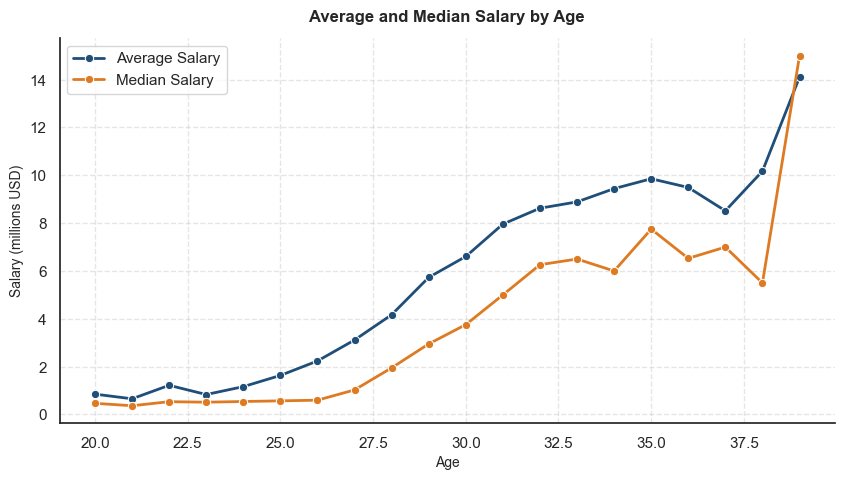

In [23]:
# Average and median salary by age
plt.figure(figsize=(10, 5))
sns.set_theme(style="white")

sns.lineplot(
    data=age_summary_filtered,
    x='age',
    y='avg_salary_millions',
    marker='o',
    color="#1f4e79",
    linewidth=2,
    label='Average Salary'
)

sns.lineplot(
    data=age_summary_filtered,
    x='age',
    y='median_salary_millions',
    marker='o',
    color="#de7a22",
    linewidth=2,
    label='Median Salary'
)

plt.grid(axis='both', linestyle='--', alpha=0.5, color="#cccccc")
sns.despine()

plt.title('Average and Median Salary by Age', fontsize=12, fontweight='bold', pad=12)
plt.xlabel('Age', fontsize=10)
plt.ylabel('Salary (millions USD)', fontsize=10)
plt.legend()

plt.show()

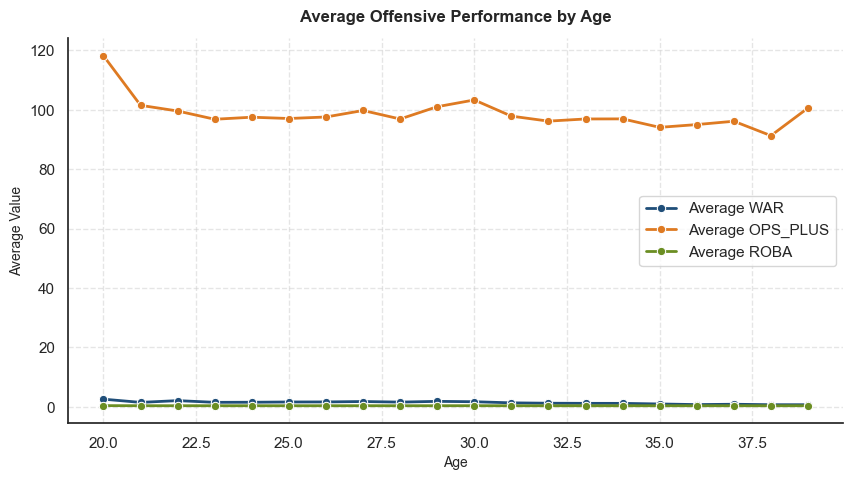

In [24]:
# Average offensive performance by age
plt.figure(figsize=(10, 5))
sns.set_theme(style="white")

sns.lineplot(
    data=age_summary_filtered,
    x='age',
    y='avg_war',
    marker='o',
    color="#1f4e79",
    linewidth=2,
    label='Average WAR'
)

sns.lineplot(
    data=age_summary_filtered,
    x='age',
    y='avg_ops_plus',
    marker='o',
    color="#de7a22",
    linewidth=2,
    label='Average OPS_PLUS'
)

sns.lineplot(
    data=age_summary_filtered,
    x='age',
    y='avg_roba',
    marker='o',
    color="#6b8e23",
    linewidth=2,
    label='Average ROBA'
)

plt.grid(axis='both', linestyle='--', alpha=0.5, color="#cccccc")
sns.despine()

plt.title('Average Offensive Performance by Age', fontsize=12, fontweight='bold', pad=12)
plt.xlabel('Age', fontsize=10)
plt.ylabel('Average Value', fontsize=10)
plt.legend()

plt.show()

### Contextual analysis: league and position

This section provides a brief contextual analysis of league and player position. Although the main focus of the project is the relationship between salary and offensive performance, league and position may help explain part of the differences observed in salary and player value.

The objective is not to expand the analysis excessively, but to review whether these contextual variables show relevant differences in salary and performance.

In [25]:
# Ensure salary in millions is available
if 'salary_millions' not in df.columns:
    df['salary_millions'] = df['salary'] / 1_000_000

In [26]:
# Summary by league
league_summary = df.groupby('lg').agg(
    records=('player', 'count'),
    unique_players=('player', 'nunique'),
    avg_salary_millions=('salary_millions', 'mean'),
    median_salary_millions=('salary_millions', 'median'),
    avg_war=('war', 'mean'),
    avg_ops=('ops', 'mean'),
    avg_roba=('roba', 'mean')
).reset_index()

league_summary

,lg,records,unique_players,avg_salary_millions,median_salary_millions,avg_war,avg_ops,avg_roba
0,2LG,180,161,2.184782,0.731376,0.663889,0.694422,0.308644
1,AL,1782,636,4.766054,1.400000,1.557688,0.726983,0.320570
2,NL,1722,600,4.867055,1.563672,1.508479,0.741276,0.328212


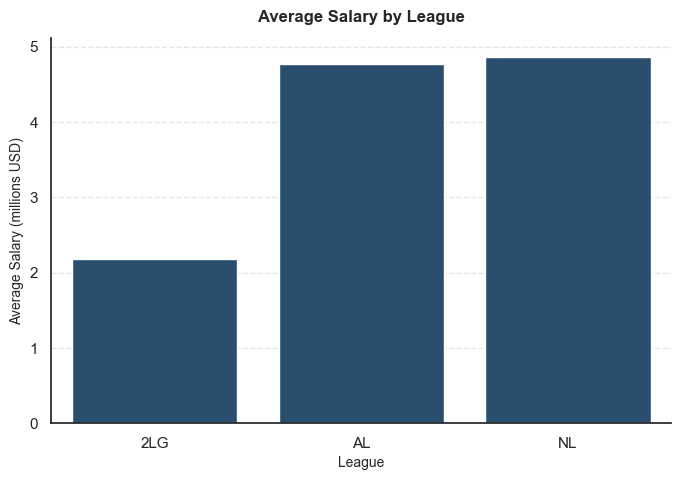

In [27]:
# Average salary by league
plt.figure(figsize=(8, 5))
sns.set_theme(style="white")

sns.barplot(
    data=league_summary,
    x='lg',
    y='avg_salary_millions',
    color="#1f4e79",
    edgecolor="white"
)

plt.grid(axis='y', linestyle='--', alpha=0.5, color="#cccccc")
sns.despine()

plt.title('Average Salary by League', fontsize=12, fontweight='bold', pad=12)
plt.xlabel('League', fontsize=10)
plt.ylabel('Average Salary (millions USD)', fontsize=10)

plt.show()

In [28]:
# Summary by position
position_summary = df.groupby('pos').agg(
    records=('player', 'count'),
    unique_players=('player', 'nunique'),
    avg_salary_millions=('salary_millions', 'mean'),
    median_salary_millions=('salary_millions', 'median'),
    avg_war=('war', 'mean'),
    avg_ops=('ops', 'mean'),
    avg_roba=('roba', 'mean')
).reset_index()

# Filter positions with enough records to avoid unstable comparisons
position_summary_filtered = position_summary[position_summary['records'] >= 30]

position_summary_filtered.sort_values(by='avg_salary_millions', ascending=False)

,pos,records,unique_players,avg_salary_millions,median_salary_millions,avg_war,avg_ops,avg_roba
606,5/H,32,20,9.532444,7.000000,2.375000,0.767188,0.335688
237,3D/H,44,30,8.453145,4.475000,1.179545,0.764659,0.334932
805,6,45,25,6.465847,4.100000,2.584444,0.723333,0.321533
1193,8/H,56,34,4.711266,3.212500,2.383929,0.720875,0.323464
821,6/H,100,48,4.694310,2.037500,2.279000,0.717990,0.317820
329,4/H,44,30,4.377833,2.453907,2.215909,0.744841,0.330318
1200,8/HD,35,23,4.091221,1.650000,2.057143,0.719571,0.319629
58,2/HD,55,44,3.471633,1.462500,1.076364,0.689109,0.305036
119,2H/D,35,32,3.082000,1.242078,1.182857,0.714971,0.316571
35,2/H,79,50,2.452136,1.125000,0.510127,0.648430,0.291228


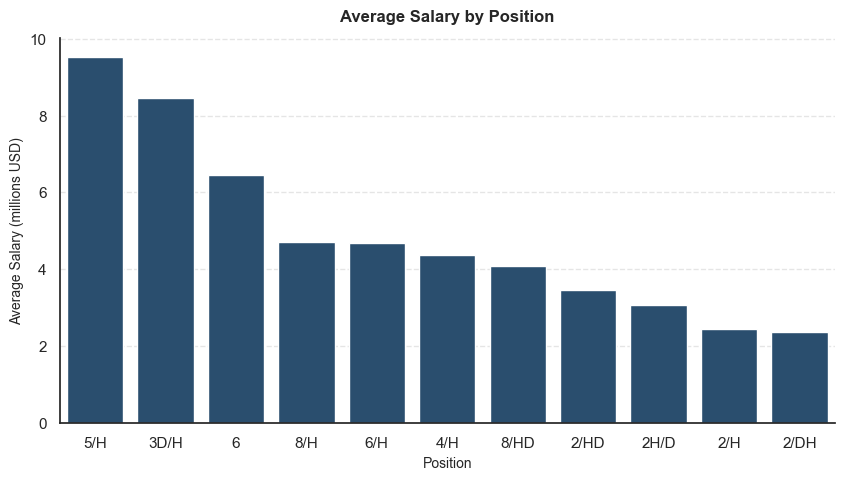

In [29]:
# Average salary by position
plt.figure(figsize=(10, 5))
sns.set_theme(style="white")

sns.barplot(
    data=position_summary_filtered.sort_values(by='avg_salary_millions', ascending=False),
    x='pos',
    y='avg_salary_millions',
    color="#1f4e79",
    edgecolor="white"
)

plt.grid(axis='y', linestyle='--', alpha=0.5, color="#cccccc")
sns.despine()

plt.title('Average Salary by Position', fontsize=12, fontweight='bold', pad=12)
plt.xlabel('Position', fontsize=10)
plt.ylabel('Average Salary (millions USD)', fontsize=10)

plt.show()

### Correlation analysis

This section analyzes the correlation between salary and the main numerical variables in the dataset. Since salary has a highly skewed distribution, the logarithmic salary variable is included to provide a more stable interpretation.

The objective is to identify which performance variables show stronger linear relationships with salary and to detect possible multicollinearity between explanatory variables.

In [30]:
# Ensure salary variables are available
if 'salary_millions' not in df.columns:
    df['salary_millions'] = df['salary'] / 1_000_000

if 'log_salary' not in df.columns:
    df['log_salary'] = np.log1p(df['salary'])

# Variables selected for correlation analysis
correlation_variables = [
    'age', 'salary_millions', 'log_salary',
    'war', 'g', 'pa',
    'hr', 'roba', 'rbi', 'bb', 'so', 'sb',
    'ba', 'obp', 'slg', 'ops', 'ops_plus'
]

# Correlation matrix
corr_matrix = df[correlation_variables].corr()

corr_matrix

,age,salary_millions,log_salary,war,g,pa,hr,roba,rbi,bb,so,sb,ba,obp,slg,ops,ops_plus
age,1.000000,0.438624,0.533297,-0.104969,0.062875,0.034148,0.011753,-0.008567,0.040323,0.077200,-0.044973,-0.158555,-0.031501,0.041212,-0.046070,-0.018046,-0.015808
salary_millions,0.438624,1.000000,0.840588,0.272785,0.288401,0.379986,0.366088,0.259382,0.400118,0.403522,0.248564,0.050286,0.185782,0.258696,0.232462,0.261660,0.274221
log_salary,0.533297,0.840588,1.000000,0.301834,0.409950,0.475755,0.395420,0.259111,0.460722,0.446315,0.313729,0.084280,0.198052,0.261575,0.228650,0.259941,0.272394
war,-0.104969,0.272785,0.301834,1.000000,0.538458,0.646519,0.662594,0.714059,0.691960,0.639305,0.455381,0.397880,0.590370,0.637226,0.649568,0.699674,0.722536
g,0.062875,0.288401,0.409950,0.538458,1.000000,0.940824,0.642194,0.312989,0.799825,0.712707,0.763424,0.371489,0.311950,0.290496,0.291002,0.315307,0.320671
pa,0.034148,0.379986,0.475755,0.646519,0.940824,1.000000,0.729161,0.428151,0.880869,0.782582,0.787609,0.394403,0.404328,0.389004,0.402407,0.431388,0.439536
hr,0.011753,0.366088,0.395420,0.662594,0.642194,0.729161,1.000000,0.623758,0.896655,0.705933,0.741549,0.136476,0.315299,0.404290,0.736677,0.677157,0.650548
roba,-0.008567,0.259382,0.259111,0.714059,0.312989,0.428151,0.623758,1.000000,0.588906,0.540744,0.310854,0.178692,0.783696,0.887896,0.913774,0.981193,0.964041
rbi,0.040323,0.400118,0.460722,0.691960,0.799825,0.880869,0.896655,0.588906,1.000000,0.743251,0.743897,0.226238,0.441798,0.445529,0.639465,0.622348,0.606976
bb,0.077200,0.403522,0.446315,0.639305,0.712707,0.782582,0.705933,0.540744,0.743251,1.000000,0.680890,0.245679,0.273798,0.600704,0.431535,0.529643,0.542509


In [31]:
# Correlation with log salary
salary_corr = corr_matrix[['log_salary']].drop(index='log_salary')
salary_corr = salary_corr.sort_values(by='log_salary', ascending=False)

salary_corr

,log_salary
salary_millions,0.840588
age,0.533297
pa,0.475755
rbi,0.460722
bb,0.446315
g,0.409950
hr,0.395420
so,0.313729
war,0.301834
ops_plus,0.272394


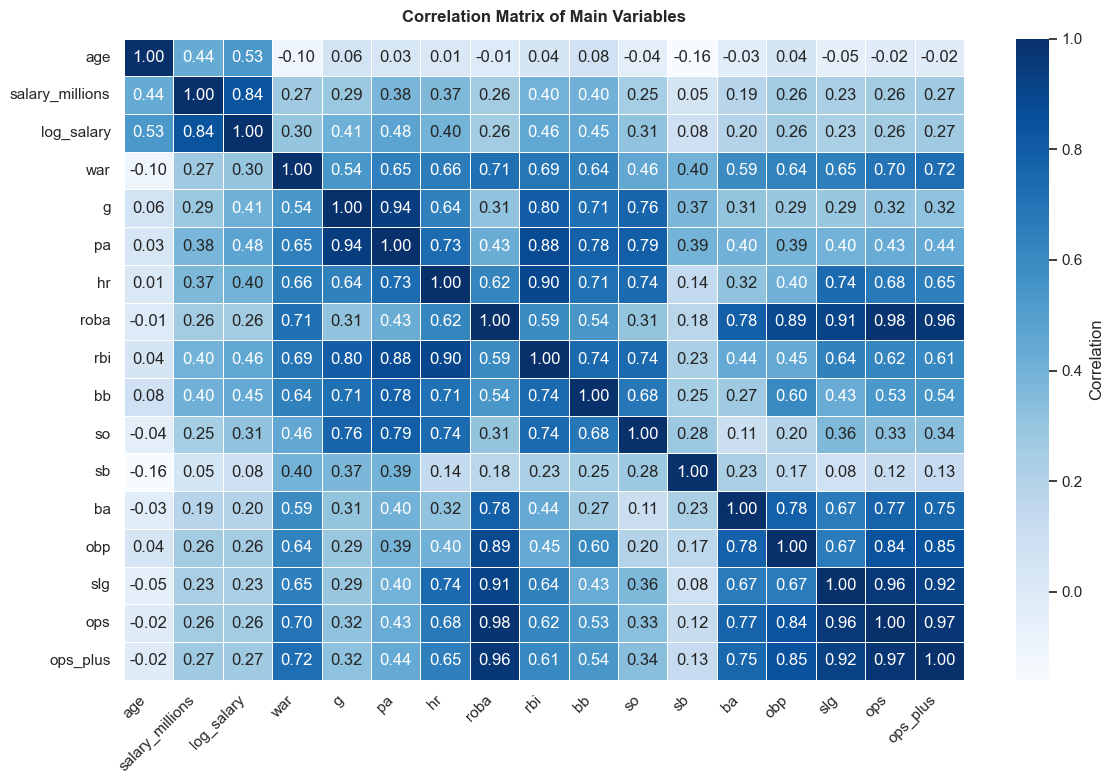

In [32]:
# Correlation heatmap
plt.figure(figsize=(12, 8))
sns.set_theme(style="white")

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    linewidths=0.5,
    linecolor="white",
    cbar_kws={'label': 'Correlation'}
)

plt.title('Correlation Matrix of Main Variables', fontsize=12, fontweight='bold', pad=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

### Relevant outliers

This section identifies relevant outliers in terms of salary and player performance. The objective is not to remove these observations, but to understand which players represent extreme cases in the dataset.

Outliers are especially important in this project because MLB salary data is highly dispersed and some players may present exceptional compensation, exceptional performance, or a mismatch between salary and performance.

In [33]:
# Columns selected to review relevant outliers
outlier_columns = [
    'year', 'player', 'player', 'team', 'lg', 'pos',
    'age', 'salary_millions', 'war', 'roba', 'ops',
    'ops_plus', 'hr', 'rbi', 'pa'
]

In [34]:
# Top 10 highest salaries
top_salaries = df[outlier_columns].sort_values(
    by='salary_millions',
    ascending=False
).head(10)

top_salaries

,year,player,player,team,lg,pos,age,salary_millions,war,roba,ops,ops_plus,hr,rbi,pa
3519,2024,will smith,will smith,LAD,NL,2/HD,29.0,44.175000,3.5,0.327,0.760,116.0,20.0,75.0,544.0
1218,2021,francisco lindor,francisco lindor,NYM,NL,6/H,27.0,43.300000,3.0,0.325,0.734,100.0,20.0,63.0,524.0
1888,2024,jose altuve,jose altuve,HOU,AL,4/DH,34.0,41.000000,3.4,0.348,0.790,126.0,20.0,65.0,682.0
21,2023,aaron judge,aaron judge,NYY,AL,9D8/H,31.0,40.000000,4.6,0.421,1.019,175.0,37.0,75.0,458.0
22,2024,aaron judge,aaron judge,NYY,AL,8D/97,32.0,40.000000,10.8,0.484,1.159,223.0,58.0,144.0,704.0
256,2024,anthony rendon,anthony rendon,LAA,AL,5/D,34.0,38.000000,0.6,0.283,0.574,66.0,0.0,14.0,238.0
839,2022,corey seager,corey seager,TEX,AL,6/D,28.0,37.500000,3.8,0.334,0.772,117.0,33.0,83.0,663.0
255,2023,anthony rendon,anthony rendon,LAA,AL,5,33.0,37.182796,0.1,0.319,0.678,89.0,2.0,22.0,183.0
604,2024,carlos correa,carlos correa,MIN,AL,6/DH,29.0,36.100000,3.7,0.393,0.905,152.0,14.0,54.0,367.0
603,2023,carlos correa,carlos correa,MIN,AL,6,28.0,36.000000,1.3,0.312,0.711,94.0,18.0,65.0,580.0


In [35]:
# Top 10 highest WAR values
top_war = df[outlier_columns].sort_values(
    by='war',
    ascending=False
).head(10)

top_war

,year,player,player,team,lg,pos,age,salary_millions,war,roba,ops,ops_plus,hr,rbi,pa
22,2024,aaron judge,aaron judge,NYY,AL,8D/97,32.0,40.000000,10.8,0.484,1.159,223.0,58.0,144.0,704.0
20,2022,aaron judge,aaron judge,NYY,AL,89D/H,30.0,19.000000,10.8,0.463,1.111,210.0,62.0,131.0,696.0
2682,2018,mookie betts,mookie betts,BOS,AL,98/HD4,25.0,10.500000,10.7,0.462,1.078,186.0,32.0,80.0,614.0
2632,2016,mike trout,mike trout,LAA,AL,8D/H,24.0,16.083333,10.4,0.435,0.991,173.0,29.0,100.0,681.0
2634,2018,mike trout,mike trout,LAA,AL,8D/H,26.0,33.250000,9.9,0.455,1.088,198.0,39.0,79.0,608.0
2680,2016,mookie betts,mookie betts,BOS,AL,9/H,23.0,0.566000,9.8,0.392,0.897,133.0,31.0,113.0,730.0
538,2015,bryce harper,bryce harper,WSN,NL,98/D,22.0,2.500000,9.7,0.466,1.109,198.0,42.0,99.0,654.0
2631,2015,mike trout,mike trout,LAA,AL,8/D,23.0,6.083000,9.5,0.419,0.991,176.0,41.0,90.0,682.0
399,2024,bobby witt jr.,bobby witt jr.,KCR,AL,6/D,24.0,12.855372,9.4,0.416,0.977,171.0,32.0,109.0,709.0
3191,2024,shohei ohtani,shohei ohtani,LAD,NL,D,29.0,2.000000,9.2,0.449,1.036,190.0,54.0,130.0,731.0


In [36]:
# High salary and low WAR cases
high_salary_threshold = df['salary_millions'].quantile(0.90)
low_war_threshold = df['war'].quantile(0.25)

high_salary_low_war = df[
    (df['salary_millions'] >= high_salary_threshold) &
    (df['war'] <= low_war_threshold)
][outlier_columns].sort_values(
    by='salary_millions',
    ascending=False
)

high_salary_low_war.head(10)

,year,player,player,team,lg,pos,age,salary_millions,war,roba,ops,ops_plus,hr,rbi,pa
255,2023,anthony rendon,anthony rendon,LAA,AL,5,33.0,37.182796,0.1,0.319,0.678,89.0,2.0,22.0,183.0
2590,2022,miguel cabrera,miguel cabrera,DET,AL,D/H,39.0,32.000000,-1.1,0.282,0.622,80.0,5.0,43.0,433.0
2591,2023,miguel cabrera,miguel cabrera,DET,AL,D/H3,40.0,32.000000,-0.3,0.308,0.675,87.0,4.0,34.0,370.0
2587,2019,miguel cabrera,miguel cabrera,DET,AL,D3/H,36.0,30.000000,0.0,0.325,0.744,97.0,12.0,59.0,549.0
2589,2021,miguel cabrera,miguel cabrera,DET,AL,D3/H,38.0,30.000000,-0.5,0.309,0.701,95.0,15.0,75.0,526.0
2585,2017,miguel cabrera,miguel cabrera,DET,AL,3D/H,34.0,28.000000,-0.9,0.321,0.728,93.0,16.0,60.0,529.0
253,2021,anthony rendon,anthony rendon,LAA,AL,5/D,31.0,27.500000,0.0,0.318,0.712,94.0,6.0,34.0,249.0
2166,2024,kris bryant,kris bryant,COL,NL,D93,32.0,27.000000,-0.7,0.292,0.623,71.0,2.0,15.0,155.0
105,2017,albert pujols,albert pujols,LAA,AL,D/3H,37.0,26.000000,-2.0,0.288,0.672,80.0,23.0,101.0,636.0
1626,2024,javier baez,javier baez,DET,AL,6/H,31.0,25.000000,-1.1,0.236,0.516,46.0,6.0,37.0,289.0


In [37]:
# Low salary and high WAR cases
low_salary_threshold = df['salary_millions'].quantile(0.25)
high_war_threshold = df['war'].quantile(0.90)

low_salary_high_war = df[
    (df['salary_millions'] <= low_salary_threshold) &
    (df['war'] >= high_war_threshold)
][outlier_columns].sort_values(
    by='war',
    ascending=False
)

low_salary_high_war.head(10)

,year,player,player,team,lg,pos,age,salary_millions,war,roba,ops,ops_plus,hr,rbi,pa
15,2017,aaron judge,aaron judge,NYY,AL,9D/H,25.0,0.5445,8.1,0.435,1.049,171.0,52.0,114.0,678.0
596,2016,carlos correa,carlos correa,HOU,AL,6/H,21.0,0.5167,7.0,0.372,0.811,124.0,20.0,96.0,660.0
2101,2015,kevin kiermaier,kevin kiermaier,TBR,AL,8H/9,25.0,0.5138,6.9,0.322,0.718,99.0,10.0,40.0,535.0
95,2015,aj pollock,aj pollock,ARI,NL,8/H,27.0,0.5195,6.8,0.389,0.865,130.0,20.0,76.0,673.0
597,2017,carlos correa,carlos correa,HOU,AL,6/D,22.0,0.5350,6.7,0.409,0.941,155.0,24.0,84.0,481.0
2781,2015,nolan arenado,nolan arenado,COL,NL,5/H,24.0,0.5125,6.3,0.378,0.898,124.0,42.0,130.0,665.0
3301,2017,tommy pham,tommy pham,STL,NL,78H/9,29.0,0.5350,6.3,0.417,0.931,144.0,23.0,73.0,530.0
2679,2015,mookie betts,mookie betts,BOS,AL,89/HD,22.0,0.5145,6.0,0.368,0.820,117.0,18.0,77.0,654.0
2102,2016,kevin kiermaier,kevin kiermaier,TBR,AL,8/H,26.0,0.5144,5.4,0.340,0.741,104.0,12.0,37.0,414.0
833,2016,corey seager,corey seager,LAD,NL,6/H,22.0,0.5100,5.2,0.379,0.877,134.0,26.0,72.0,687.0


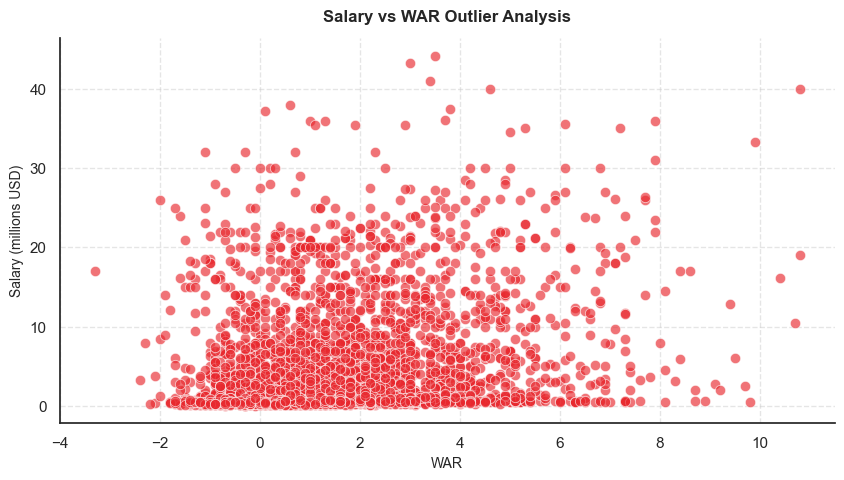

In [38]:
# Salary vs WAR outlier visualization
plt.figure(figsize=(10, 5))
sns.set_theme(style="white")

sns.scatterplot(
    data=df,
    x='war',
    y='salary_millions',
    color="#e8282e",
    alpha=0.65,
    edgecolor="white",
    s=55
)

plt.grid(axis='both', linestyle='--', alpha=0.5, color="#cccccc")
sns.despine()

plt.title('Salary vs WAR Outlier Analysis', fontsize=12, fontweight='bold', pad=12)
plt.xlabel('WAR', fontsize=10)
plt.ylabel('Salary (millions USD)', fontsize=10)

plt.show()

### EDA conclusions

The exploratory data analysis provided a clear overview of the final integrated MLB hitters dataset. The dataset contains complete and consistent information from 2015 to 2024, including salary, player characteristics, traditional offensive metrics and sabermetric indicators.

One of the main findings is that salary presents a highly right-skewed distribution, with most players concentrated in lower and medium salary ranges and a smaller group receiving substantially higher compensation. For this reason, the logarithmic transformation of salary was useful to improve visualization and interpretation.

The analysis of offensive performance showed relevant differences between traditional metrics and sabermetric metrics. Traditional variables such as HR, RBI, BB, SO, SB and BA provide useful information about hitter production, but some of them are strongly influenced by playing time and opportunities. In contrast, sabermetric variables such as WAR, ROBA, OPS, OPS+, OBP and SLG offer a broader view of player contribution and offensive value.

The salary-performance analysis suggested that player compensation is related to offensive contribution, although the relationship is not perfectly linear. Variables such as WAR, ROBA, OPS, OPS+ and PA appear especially relevant for understanding salary differences.

The temporal and age analyses showed that salary and performance may vary across seasons and career stages. These variables provide important context and may be useful in later modeling phases.

Finally, the outlier analysis confirmed the presence of extreme cases in both salary and performance. These observations should not be automatically removed, as they may reflect real MLB market dynamics, contract structure, player experience or exceptional performance.

Overall, this EDA confirms that the dataset is suitable for the next stages of the project. The analysis supports the idea that advanced performance metrics may provide valuable information when studying the relationship between MLB hitter performance and salary.